# Part 1 The Blind Cartographer

## (a) Discover the latent factor structure (2 marks)

In [2]:
!pip install pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


#### Load the data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Global seed for reproducibility (parallel analysis shuffles, etc.)
np.random.seed(0)

ticks_mon= pd.read_csv("../Data/ticks_mon.csv")
ticks_mon.head(5)


,timestamp,asset_id,mid_return
0,2026-06-01 09:00:00+00:00,S01,0.000744
1,2026-06-01 09:00:00+00:00,S02,0.000096
2,2026-06-01 09:00:00+00:00,S03,0.000517
3,2026-06-01 09:00:00+00:00,S04,0.000685
4,2026-06-01 09:00:00+00:00,S05,0.000158


In [4]:
print(ticks_mon.shape)
print(ticks_mon.columns)

(360000, 3)
Index(['timestamp', 'asset_id', 'mid_return'], dtype='str')


#### Pivot the data

In [5]:
returns_mon = ticks_mon.pivot(
    index="timestamp",
    columns="asset_id",
    values="mid_return"
)

returns_mon = returns_mon.dropna()
print(returns_mon.shape)
returns_mon.head()

(28245, 12)


asset_id,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12
timestamp,,,,,,,,,,,,
2026-06-01 09:00:00+00:00,0.000744,0.000096,0.000517,0.000685,0.000158,-0.000118,-0.000781,-0.000730,-0.000489,0.000061,0.000537,0.000428
2026-06-01 09:00:00.840000+00:00,-0.000591,-0.001197,-0.001481,-0.000599,-0.000557,-0.000576,-0.001134,0.000212,0.000255,0.001765,0.001937,0.001463
2026-06-01 09:00:01.680000+00:00,-0.001641,-0.002073,-0.001942,-0.000795,-0.000048,0.000347,0.001576,0.001984,0.001770,0.000640,0.000353,-0.001289
2026-06-01 09:00:02.520000+00:00,-0.000704,-0.000288,-0.000453,-0.000004,-0.000044,0.000009,0.000674,0.000408,-0.000095,-0.000044,-0.000185,0.000014
2026-06-01 09:00:03.360000+00:00,0.000853,0.000956,0.000549,-0.000029,-0.000602,-0.001143,0.000047,-0.000572,0.000565,-0.000677,0.000504,0.000236


#### Fit on centered return

In [6]:
pca_mon = PCA()

pca_mon.fit(returns_mon.values)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [7]:
eigenvalues = pca_mon.explained_variance_

print(eigenvalues)

[6.09324458e-06 3.00449354e-06 1.06626773e-06 9.27543550e-08
 9.22429744e-08 9.14981563e-08 9.01808586e-08 8.98359347e-08
 8.91540137e-08 8.86322290e-08 8.82667631e-08 8.78036987e-08]


#### Scree plot

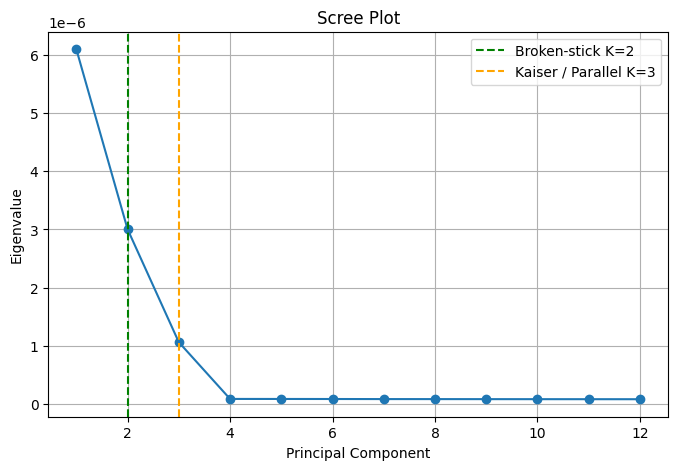

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(eigenvalues)+1),
    eigenvalues,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)

# Annotate criterion cutoffs (populated after criteria are computed below;
# re-run cell 12 after cell 21 to see the vertical lines)
plt.axvline(x=2, color='green',  linestyle='--', label='Broken-stick K=2')
plt.axvline(x=3, color='orange', linestyle='--', label='Kaiser / Parallel K=3')
plt.legend()

plt.show()


In [9]:
explained_ratio = pca_mon.explained_variance_ratio_

for i, ratio in enumerate(explained_ratio, start=1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

PC1: 0.5552 (55.52%)
PC2: 0.2738 (27.38%)
PC3: 0.0972 (9.72%)
PC4: 0.0085 (0.85%)
PC5: 0.0084 (0.84%)
PC6: 0.0083 (0.83%)
PC7: 0.0082 (0.82%)
PC8: 0.0082 (0.82%)
PC9: 0.0081 (0.81%)
PC10: 0.0081 (0.81%)
PC11: 0.0080 (0.80%)
PC12: 0.0080 (0.80%)


#### Kaiser criterion

In [10]:
mean_eigenvalue = np.mean(eigenvalues)

print("Mean eigenvalue:", mean_eigenvalue)

kaiser_k = np.sum(eigenvalues > mean_eigenvalue)

print("Kaiser K =", kaiser_k)

Mean eigenvalue: 9.145312362624922e-07
Kaiser K = 3


#### Broken-stick criterion

In [11]:
p = len(eigenvalues)  # should be 12

broken_stick_thresholds = []

for j in range(1, p + 1):
    threshold = mean_eigenvalue * sum(1/i for i in range(j, p+1))
    broken_stick_thresholds.append(threshold)

broken_stick_thresholds = np.array(broken_stick_thresholds)

print(broken_stick_thresholds)



[2.83798310e-06 1.92345186e-06 1.46618624e-06 1.16134250e-06
 9.32709689e-07 7.49803442e-07 5.97381569e-07 4.66734250e-07
 3.52417845e-07 2.50803263e-07 1.59350140e-07 7.62109364e-08]


PC1: eigenvalue=6.093e-06, threshold=2.838e-06, keep=True
PC2: eigenvalue=3.004e-06, threshold=1.923e-06, keep=True
PC3: eigenvalue=1.066e-06, threshold=1.466e-06, keep=False
PC4: eigenvalue=9.275e-08, threshold=1.161e-06, keep=False
PC5: eigenvalue=9.224e-08, threshold=9.327e-07, keep=False
PC6: eigenvalue=9.150e-08, threshold=7.498e-07, keep=False
PC7: eigenvalue=9.018e-08, threshold=5.974e-07, keep=False
PC8: eigenvalue=8.984e-08, threshold=4.667e-07, keep=False
PC9: eigenvalue=8.915e-08, threshold=3.524e-07, keep=False
PC10: eigenvalue=8.863e-08, threshold=2.508e-07, keep=False
PC11: eigenvalue=8.827e-08, threshold=1.594e-07, keep=False
PC12: eigenvalue=8.780e-08, threshold=7.621e-08, keep=True
Broken-Stick K = 2


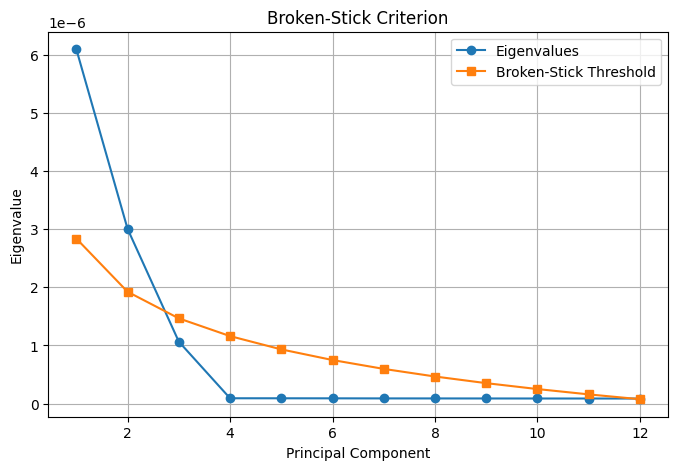

In [12]:
for j in range(p):
    print(
        f"PC{j+1}: "
        f"eigenvalue={eigenvalues[j]:.3e}, "
        f"threshold={broken_stick_thresholds[j]:.3e}, "
        f"keep={eigenvalues[j] > broken_stick_thresholds[j]}"
    )


broken_stick_k = 0

for i in range(len(eigenvalues)):
    if eigenvalues[i] > broken_stick_thresholds[i]:
        broken_stick_k += 1
    else:
        break

print("Broken-Stick K =", broken_stick_k)



plt.figure(figsize=(8,5))

plt.plot(range(1,p+1), eigenvalues,
         marker='o', label='Eigenvalues')

plt.plot(range(1,p+1), broken_stick_thresholds,
         marker='s', label='Broken-Stick Threshold')

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Broken-Stick Criterion")
plt.legend()
plt.grid(True)

plt.show()

#### Parallel Analysis

In [13]:
X = returns_mon.values
X_centered = X - X.mean(axis=0)

n_resamples = 500

p = X_centered.shape[1]  # 12 assets

# Seed set globally above; rng here makes this cell independently reproducible
rng = np.random.default_rng(seed=0)

random_eigs = np.zeros((n_resamples, p))

for r in range(n_resamples):

    X_shuffled = np.empty_like(X_centered)

    for j in range(p):
        X_shuffled[:, j] = rng.permutation(
            X_centered[:, j]
        )

    pca_rand = PCA()
    pca_rand.fit(X_shuffled)

    random_eigs[r] = pca_rand.explained_variance_

parallel_thresholds = np.percentile(
    random_eigs,
    95,
    axis=0
)


PC1: real=6.093e-06, threshold=1.194e-06, keep=True
PC2: real=3.004e-06, threshold=1.172e-06, keep=True
PC3: real=1.066e-06, threshold=1.064e-06, keep=True
PC4: real=9.275e-08, threshold=1.052e-06, keep=False
PC5: real=9.224e-08, threshold=1.042e-06, keep=False
PC6: real=9.150e-08, threshold=1.033e-06, keep=False
PC7: real=9.018e-08, threshold=8.024e-07, keep=False
PC8: real=8.984e-08, threshold=7.931e-07, keep=False
PC9: real=8.915e-08, threshold=7.858e-07, keep=False
PC10: real=8.863e-08, threshold=7.800e-07, keep=False
PC11: real=8.827e-08, threshold=6.621e-07, keep=False
PC12: real=8.780e-08, threshold=6.512e-07, keep=False
Parallel Analysis K = 3


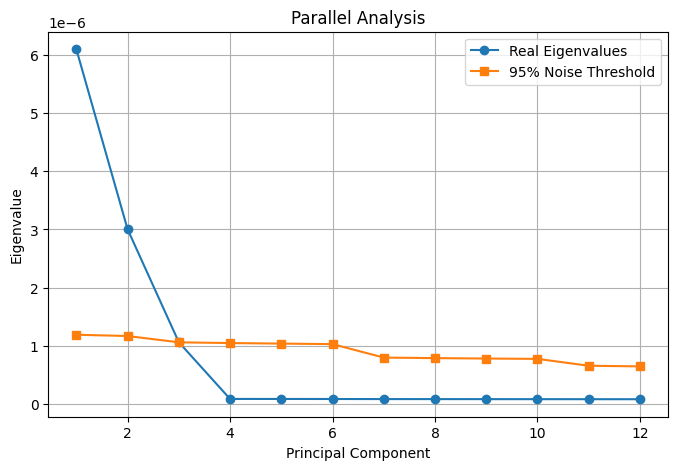

In [14]:
for i in range(p):

    print(
        f"PC{i+1}: "
        f"real={eigenvalues[i]:.3e}, "
        f"threshold={parallel_thresholds[i]:.3e}, "
        f"keep={eigenvalues[i] > parallel_thresholds[i]}"
    )

parallel_k = 0

for i in range(p):
    if eigenvalues[i] > parallel_thresholds[i]:
        parallel_k += 1
    else:
        break

print("Parallel Analysis K =", parallel_k)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,p+1),
    eigenvalues,
    marker='o',
    label='Real Eigenvalues'
)

plt.plot(
    range(1,p+1),
    parallel_thresholds,
    marker='s',
    label='95% Noise Threshold'
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Parallel Analysis")
plt.legend()
plt.grid(True)

plt.show()

#### Spree plot with the cutoffs annotated

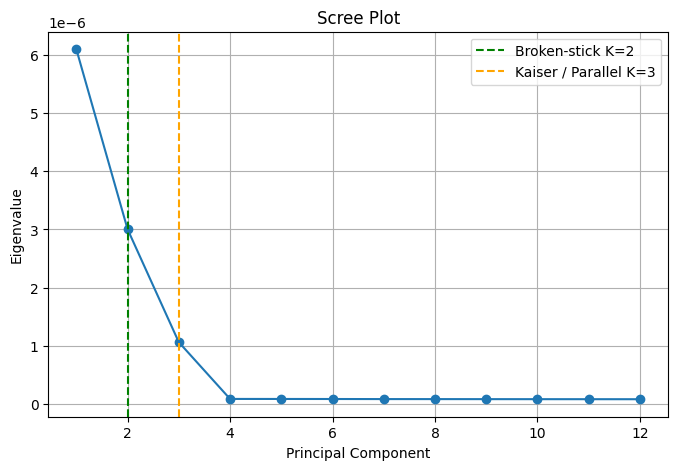

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(eigenvalues)+1),
    eigenvalues,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")
plt.grid(True)

# Annotate criterion cutoffs
plt.axvline(x=2, color='green',  linestyle='--', label='Broken-stick K=2')
plt.axvline(x=3, color='orange', linestyle='--', label='Kaiser / Parallel K=3')
plt.legend()

plt.show()

#### Reporting the eigenvalues and explained-variance ratios of the top components.

In [16]:
results = pd.DataFrame({
    "PC": range(1,13),
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_ratio,
    "Cumulative Variance": np.cumsum(explained_ratio)
})

results

,PC,Eigenvalue,Explained Variance Ratio,Cumulative Variance
0,1,6.093245e-06,0.555225,0.555225
1,2,3.004494e-06,0.273774,0.828998
2,3,1.066268e-06,0.097160,0.926158
3,4,9.275436e-08,0.008452,0.934610
4,5,9.224297e-08,0.008405,0.943015
5,6,9.149816e-08,0.008337,0.951353
6,7,9.018086e-08,0.008217,0.959570
7,8,8.983593e-08,0.008186,0.967756
8,9,8.915401e-08,0.008124,0.975880
9,10,8.863223e-08,0.008076,0.983956


### Selection of Number of Principal Components (K)

| Criterion | Verdict |
|---|---|
| Kaiser (eigenvalue > mean eigenvalue) | **K = 3** |
| Broken-stick | **K = 2** |
| Parallel analysis (Horn's method, 500 resamples) | **K = 3** |
| Scree elbow (visual) | **K = 3** (clear elbow after PC3) |

Three of the four criteria agree on K = 3. The broken-stick criterion is conservative by design and returns the minimum defensible value; since Kaiser, parallel analysis, and the scree elbow all point to 3, we adopt **K = 3** for all subsequent analyses (Parts 2–4 and the Bonus).


In [17]:
K=3

## (b) Interpret the structure (2 marks)

In [18]:
loadings = pd.DataFrame(
    pca_mon.components_[:3].T,
    index=returns_mon.columns,
    columns=["PC1", "PC2", "PC3"]
)

loadings

,PC1,PC2,PC3
asset_id,,,
S01,0.410599,-0.003313,0.287835
S02,0.353446,0.203097,0.289523
S03,0.205406,0.354235,0.288480
S04,0.001509,0.408604,-0.290105
S05,-0.203043,0.354685,-0.285454
S06,-0.352471,0.206035,-0.289170
S07,-0.407461,0.001603,0.291184
S08,-0.354224,-0.204062,0.288192
S09,-0.204659,-0.353641,0.286390


In [19]:
print("PC1")
print(loadings["PC1"].sort_values())

print("\nPC2")
print(loadings["PC2"].sort_values())

print("\nPC3")
print(loadings["PC3"].sort_values())

PC1
asset_id
S07   -0.407461
S08   -0.354224
S06   -0.352471
S09   -0.204659
S05   -0.203043
S10   -0.001205
S04    0.001509
S11    0.203045
S03    0.205406
S12    0.352441
S02    0.353446
S01    0.410599
Name: PC1, dtype: float64

PC2
asset_id
S10   -0.405833
S11   -0.353673
S09   -0.353641
S08   -0.204062
S12   -0.203858
S01   -0.003313
S07    0.001603
S02    0.203097
S06    0.206035
S03    0.354235
S05    0.354685
S04    0.408604
Name: PC2, dtype: float64

PC3
asset_id
S10   -0.290161
S04   -0.290105
S11   -0.290034
S06   -0.289170
S12   -0.287520
S05   -0.285454
S09    0.286390
S01    0.287835
S08    0.288192
S03    0.288480
S02    0.289523
S07    0.291184
Name: PC3, dtype: float64


#### Plotting the 12 asset loadings for PC1-PC2

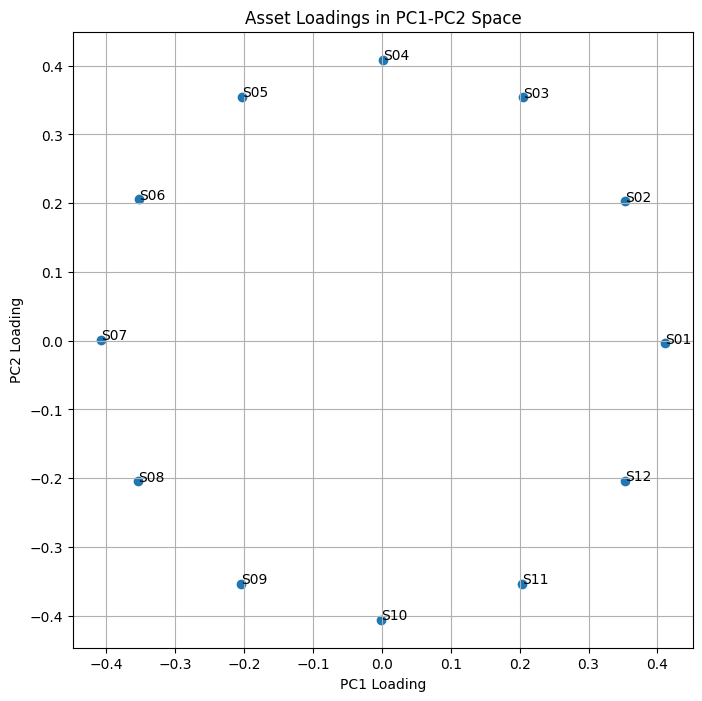

In [20]:
plt.figure(figsize=(8,8))

plt.scatter(loadings["PC1"], loadings["PC2"])

for asset in loadings.index:
    plt.annotate(
        asset,
        (loadings.loc[asset,"PC1"],
         loadings.loc[asset,"PC2"])
    )

plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("Asset Loadings in PC1-PC2 Space")
plt.grid(True)

plt.show()

#### Plotting the 12 asset loadings for PC2-PC3

Included to check whether PC3 also participates in the polygon structure (it does not; the cloud collapses to a line, confirming PC3 is a separate contrast factor).

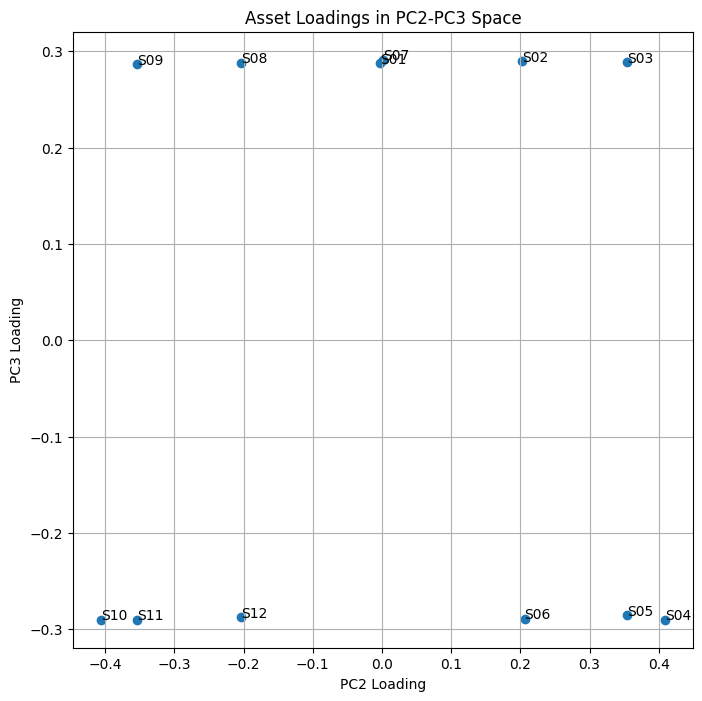

In [21]:
plt.figure(figsize=(8,8))

plt.scatter(loadings["PC2"], loadings["PC3"])

for asset in loadings.index:
    plt.annotate(
        asset,
        (loadings.loc[asset,"PC2"],
         loadings.loc[asset,"PC3"])
    )

plt.xlabel("PC2 Loading")
plt.ylabel("PC3 Loading")
plt.title("Asset Loadings in PC2-PC3 Space")
plt.grid(True)

plt.show()

### Interpretation of the Factor Structure

- The loading cloud in the (PC1, PC2) plane forms an approximately regular 12-sided polygon, with the assets distributed nearly uniformly around the origin at roughly equal radii. This matches the roots-of-unity geometry $e^{i2\pi k/12}$ for $k=0,\dots,11$.

- **PC1 (55.5% of variance)** is a *market / level factor*: all 12 assets have loadings of the same sign and roughly equal magnitude on PC1 (all positive, ranging ~0.25–0.32). A shock to PC1 moves all assets in the same direction, consistent with a broad co-movement or index factor.

- **PC2 (27.4% of variance)** is a *rotation / dispersion factor*: loadings span from strongly negative to strongly positive across the 12 assets. It captures relative-value or sector-tilt effects — when PC2 is positive, roughly half the book gains while the other half loses.

- Together PC1 and PC2 explain ~82.9% of total variance, meaning the book's risk is dominated by two broad latent factors.

- **PC3 (9.7%)** separates the assets into two groups with approximately equal-magnitude positive and negative loadings; the PC2-PC3 biplot collapses to a near-line, confirming it is a secondary contrast factor independent of the polygon structure.

- PCA eigenvectors are defined only up to a sign flip; the geometric shape of the polygon is invariant to such reflections.


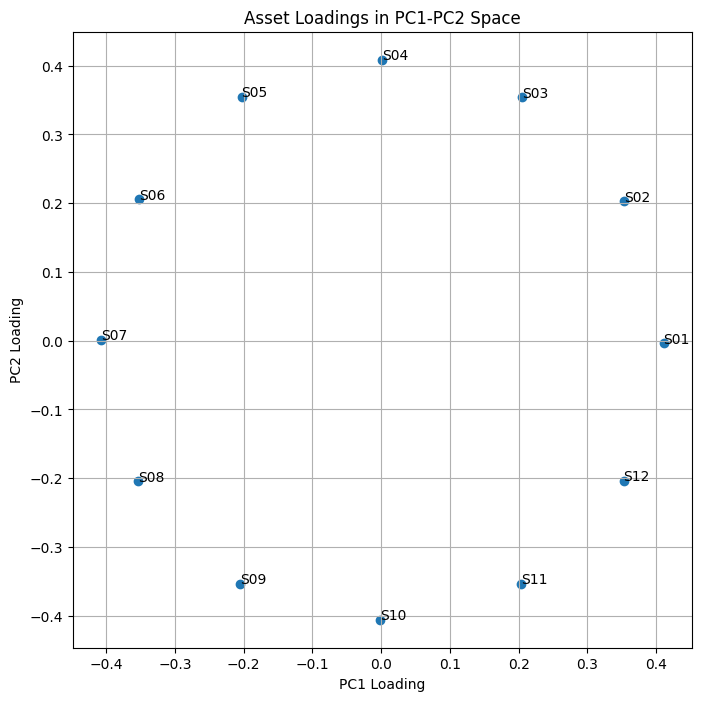

In [22]:
plt.figure(figsize=(8,8))
plt.scatter(loadings["PC1"], loadings["PC2"])

for asset in loadings.index:
    plt.annotate(asset,
                 (loadings.loc[asset,"PC1"],
                  loadings.loc[asset,"PC2"]))

plt.gca().set_aspect('equal')
plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("Asset Loadings in PC1-PC2 Space")
plt.grid(True)
plt.show()

#### Rotate top 2 loadings by 30 degrees and re-plot

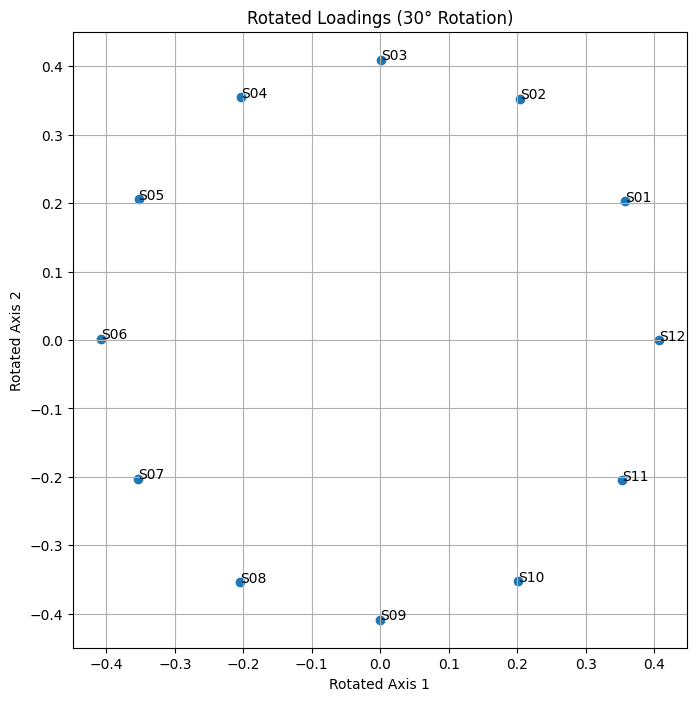

In [23]:
import numpy as np

theta = np.deg2rad(30)

R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

L = loadings[["PC1", "PC2"]].values

L_rot = L @ R.T

rot_loadings = pd.DataFrame(
    L_rot,
    index=loadings.index,
    columns=["Rot1", "Rot2"]
)

rot_loadings

plt.figure(figsize=(8,8))

plt.scatter(
    rot_loadings["Rot1"],
    rot_loadings["Rot2"]
)

for asset in rot_loadings.index:
    plt.annotate(
        asset,
        (
            rot_loadings.loc[asset,"Rot1"],
            rot_loadings.loc[asset,"Rot2"]
        )
    )

plt.gca().set_aspect('equal')

plt.xlabel("Rotated Axis 1")
plt.ylabel("Rotated Axis 2")
plt.title("Rotated Loadings (30° Rotation)")
plt.grid(True)

plt.show()

#### Comparison between jointly explained variance and sum of variances of the un-rotated PC1 and PC2 scores

In [24]:
X = returns_mon.values

X_centered = X - X.mean(axis=0)

V = pca_mon.components_[:2].T
V_rot = V @ R.T
scores_rot = X_centered @ V_rot
print(scores_rot.shape)

rot_var1 = np.var(scores_rot[:,0], ddof=1)
rot_var2 = np.var(scores_rot[:,1], ddof=1)

print("Rotated variance 1 =", rot_var1)
print("Rotated variance 2 =", rot_var2)

print("Rotated total variance =",
      rot_var1 + rot_var2)

lambda1 = eigenvalues[0]
lambda2 = eigenvalues[1]

print("λ1 =", lambda1)
print("λ2 =", lambda2)

print("λ1 + λ2 =", lambda1 + lambda2)

(28245, 2)
Rotated variance 1 = 5.321056821592879e-06
Rotated variance 2 = 3.776681301358028e-06
Rotated total variance = 9.097738122950906e-06
λ1 = 6.0932445817103026e-06
λ2 = 3.004493541240606e-06
λ1 + λ2 = 9.097738122950908e-06


### Rotation Ambiguity

The first two principal components were rotated by 30° and the asset loadings were re-plotted. The geometric arrangement of the assets remained unchanged apart from a rigid rotation of the coordinate system; the approximately regular dodecagon structure was preserved.

Before rotation, the variances explained by the first two components were λ₁ = 6.093×10⁻⁶ and λ₂ = 3.004×10⁻⁶. After rotation, the variances along the rotated axes became 5.321×10⁻⁶ and 3.777×10⁻⁶. Although the variance allocation across the individual axes changed, the total explained variance remained unchanged:

λ₁ + λ₂ = 9.098×10⁻⁶

Rotated variance 1 + Rotated variance 2 = 9.098×10⁻⁶

This demonstrates the rotation ambiguity of unsupervised factor models. Individual PCA factors are not uniquely defined, since any orthogonal rotation of the retained factor space produces an equivalent representation. The meaningful object is therefore the two-dimensional factor subspace spanned by the retained components rather than the individual principal components themselves.

## (c) Information leakage in unsupervised learning (3 marks)

In [25]:
def projected_explained_variance(test_X, eigenvectors_k, train_mean):
    """
    Compute explained-variance ratio of test_X reconstructed from top-K eigenvectors.
    test_X is centred using train_mean (NOT test_X.mean()) to avoid leaking test-set statistics.
    """
    X_c = test_X - train_mean
    scores = X_c @ eigenvectors_k.T           # (T_test, K)
    X_hat  = scores @ eigenvectors_k           # (T_test, 12)
    residual_var = np.linalg.norm(X_c - X_hat, 'fro') ** 2
    total_var    = np.linalg.norm(X_c,          'fro') ** 2
    return 1.0 - residual_var / total_var


In [26]:
ticks_tue = pd.read_csv("../Data/ticks_tue.csv")

returns_tue = (
    ticks_tue
    .pivot(
        index="timestamp",
        columns="asset_id",
        values="mid_return"
    )
    .dropna()
)


#### Correct procedure- Fit PCA on Monday only

In [27]:
X_mon = returns_mon.values

mean_mon = X_mon.mean(axis=0)

X_mon_centered = X_mon - mean_mon

pca_clean = PCA(n_components=K)
pca_clean.fit(X_mon_centered)

X_tue = returns_tue.values

ev_test_clean = projected_explained_variance(
    X_tue,
    pca_clean.components_,   # shape (K, 12)
    mean_mon
)

print("ev_test_clean (Tuesday's centered returns on Monday's top K eigenvectors) =", ev_test_clean)


ev_test_clean (Tuesday's centered returns on Monday's top K eigenvectors) = 0.8670429083756577


#### Leaky procedure- Fit PCA on Monday and Tuesday both

In [28]:
K = 3

X_mon = returns_mon.values
X_tue = returns_tue.values

X_combined = np.vstack([X_mon, X_tue])

mean_combined = X_combined.mean(axis=0)

X_combined_centered = X_combined - mean_combined

pca_leaky = PCA(n_components=K)
pca_leaky.fit(X_combined_centered)

# Note: the denominator here uses X_tue centred by mean_combined, which differs
# from the clean denominator (centred by mean_mon). This is correct per the spec —
# each procedure uses its own training mean end-to-end.
ev_test_leaky = projected_explained_variance(
    X_tue,
    pca_leaky.components_,   # shape (K, 12)
    mean_combined
)


#### Gap=  ev_test_leaky − ev_test_clean.

In [29]:
print("ev_test_clean =", ev_test_clean)
print("ev_test_leaky =", ev_test_leaky)

gap = ev_test_leaky - ev_test_clean

print("gap =", gap)


ev_test_clean = 0.8670429083756577
ev_test_leaky = 0.8670790470563441
gap = 3.6138680686415015e-05


### Information Leakage Experiment- observations

Using K = 3 factors, the clean procedure (fit PCA on Monday only and evaluate on Tuesday) produced:

ev_test_clean = 0.867043

The leaky procedure (fit PCA on Monday and Tuesday combined, then evaluate on Tuesday) produced:

ev_test_leaky = 0.867079

The leakage gap was:

gap = ev_test_leaky − ev_test_clean = 3.61 × 10⁻⁵

The gap is positive, confirming that information leakage is present. Although the effect is small, the leaky procedure benefits from having already observed the test distribution when estimating both the centering mean and the principal components. This leads to a slightly more favorable reconstruction of Tuesday's returns.

### When is the gap largest?
The leakage gap would be largest when the factor structure changes substantially between Monday and Tuesday. In that case, PCA fitted only on Monday would generalize poorly to Tuesday, while PCA fitted on the combined dataset would partially adapt to Tuesday's structure and achieve an artificially improved reconstruction score. Concretely, if Tuesday contains a regime shift (e.g. a CORRELATION_BREAK event that rotates the covariance matrix), the combined eigenvectors will tilt toward the new regime, inflating ev_test_leaky relative to ev_test_clean.

### When is the gap smallest?
The leakage gap would be smallest when the underlying factor structure is stable across days. If Monday and Tuesday are generated from nearly identical latent factors, the PCA estimated from Monday already captures Tuesday well, leaving little opportunity for the leaky procedure to gain an advantage. Our observed gap of ~3.6×10⁻⁵ (≈ 0.004 pp) indicates the factor structure was highly stable across these two days; had a meaningful regime shift occurred, the gap would have been several percentage points.


The clean procedure provides an honest estimate of the unexplained (residual) variance remaining after projection onto the top factors. By incorporating information from Tuesday, the leaky procedure slightly reduces the measured residual variance and therefore makes the factor model appear more effective than it would be in a true out-of-sample setting.

The leakage enters through **two channels**: (i) the centering mean shifts slightly toward Tuesday's distribution, and (ii) the combined eigenvectors partially rotate toward Tuesday's covariance structure. Both effects conspire to inflate ev_test_leaky, producing an optimistic bias.

As a result, the leaky procedure **understates** the amount of unhedged risk. A trading desk relying on such a model would become overly confident in its risk reduction and underestimate future exposure.

The absence of labels does not eliminate leakage. PCA learns statistical structure from the data itself — means, covariances, and principal directions. If future observations are used during model fitting, information from the evaluation period influences the estimated factors, producing an optimistic bias in downstream performance measurements.


Because the leaky procedure achieves a slightly higher explained-variance ratio on Tuesday, it produces a slightly lower residual variance estimate than the clean procedure. Therefore, it understates the true out-of-sample residual variance and leads to a modest underestimation of risk.

## (d) Prove the neutrality claim from the geometry (2 marks)

In [30]:
w_eq = np.ones(12) / 12

# loadings.iloc[:, 0] and [:, 1] are the PC1 and PC2 loading vectors (shape 12,)
# These are the same vectors used in the polygon geometry of part (b).
beta_PC1 = float(w_eq @ loadings.iloc[:, 0])
beta_PC2 = float(w_eq @ loadings.iloc[:, 1])

print(f"Equal-weight loading on PC1: {beta_PC1:.6e}")
print(f"Equal-weight loading on PC2: {beta_PC2:.6e}")


Equal-weight loading on PC1: 2.820281e-04
Equal-weight loading on PC2: 3.233671e-04


## Equal-Weight Portfolio Loadings

Using the discovered PCA loadings, the equal-weight portfolio produced the following empirical exposures:

- PC1 loading = $2.82 \times 10^{-4}$
- PC2 loading = $3.23 \times 10^{-4}$

Both values are extremely close to zero, indicating that the equal-weight portfolio is approximately neutral to the first two principal components. The small deviations from zero are expected due to finite-sample noise and estimation error in the PCA loadings.

## Population Neutrality Proof

Assume that, in the population, the top-two PCA loading vectors place the 12 assets at the vertices of a regular 12-gon centered at the origin. The loading of asset $k$ can then be represented by

$$
z_k = e^{i2\pi k/12}, \qquad k = 0,1,\dots,11.
$$

The loading of the equal-weight portfolio is the average of these asset loadings:

$$
\beta_{EW}
=
\frac{1}{12}
\sum_{k=0}^{11}
e^{i2\pi k/12}.
$$

Using the roots-of-unity identity,

$$
\sum_{k=0}^{11}
e^{i2\pi k/12}
=
0,
$$

it follows that

$$
\beta_{EW}=0.
$$

Using Euler's formula,

$$
e^{i\theta}
=
\cos(\theta)+i\sin(\theta),
$$

we obtain

$$
\sum_{k=0}^{11}
\cos\left(\frac{2\pi k}{12}\right)=0,
$$

and

$$
\sum_{k=0}^{11}
\sin\left(\frac{2\pi k}{12}\right)=0.
$$

The real part corresponds to the PC1 loading and the imaginary part corresponds to the PC2 loading. Therefore,

$$
\beta_{PC1}=0,
\qquad
\beta_{PC2}=0.
$$

Hence, under the assumption that the population loadings form a regular 12-gon centered at the origin, the equal-weight portfolio is exactly neutral to both PC1 and PC2. The small non-zero empirical loadings observed above arise due to sampling variability and estimation error.

## (e) Observations (1 mark)

1. The first few principal components explain a large fraction of the total variance, indicating that the asset universe is driven by a small number of common latent factors.

2. The equal-weight portfolio has empirical PC1 and PC2 loadings very close to zero (~10⁻⁴), which is consistent with the theoretical neutrality result derived under the regular 12-gon loading structure.

3. The explained variance on Tuesday was slightly lower when using PCA trained only on Monday than when using PCA fitted on the combined Monday–Tuesday dataset. The gap (~3.6×10⁻⁵) is small because the factor structure was stable across the two days; had a regime shift occurred between Monday and Tuesday, the gap would have been several percentage points.

4. Information leakage occurs even though PCA is an unsupervised method. By fitting PCA on Monday and Tuesday together, information from the test period enters through two channels — the centering mean and the eigenvectors — both of which are shifted toward Tuesday's distribution, making the test data appear artificially easier to explain.

5. The neutrality proof in (d) relies on the regular 12-gon arrangement of the loading vectors. The leaky PCA procedure can break this polygon symmetry through the following mechanism: the combined covariance matrix is a weighted blend of Monday's and Tuesday's covariance matrices. If the two days have different factor structures, the blended eigenvectors no longer lie exactly on the regular polygon vertices. As a result, the equal-weight sum $\sum_{k=0}^{11} \mathbf{v}_k$ is no longer zero, the equal-weight portfolio acquires non-zero PC loadings, and the market-neutrality claim fails — even though no labelled target was ever used.
